# DDPM Diffusion Model for MNIST

This notebook implements a minimal **Denoising Diffusion Probabilistic Model (DDPM)** in PyTorch for handwritten digit generation on MNIST. The notation and derivations follow the DDPM presentation summarized in Lilian Weng's diffusion-model overview.

What it covers:

- MNIST loading with `torchvision`, normalized to `[-1, 1]`
- Forward diffusion with a fixed linear beta schedule over 1000 timesteps
- The closed-form marginal `q(x_t | x_0)` used by the reparameterization trick
- A compact U-Net with sinusoidal time embeddings
- The reverse posterior and the noise-prediction parameterization of its mean
- Why the simplified MSE noise objective is connected to the variational bound
- Sampling from pure Gaussian noise back to generated digits
- Visualizations for noising, loss, generated samples, and denoising trajectory

Run all cells from top to bottom. On CPU this is educational but slow; on GPU it should train much faster.

## 1. Imports and Configuration

DDPM defines a fixed noising process `q` and learns a reverse process `p_theta`. We normalize MNIST images to `[-1, 1]`, because the standard DDPM beta schedule is calibrated for normalized pixel values and the reverse sampler assumes outputs live in the same range.

The schedule here uses the original DDPM-style linear variance values

$$
\beta_1 = 10^{-4}, \qquad \beta_T = 0.02, \qquad T = 1000.
$$

In code, timesteps are zero-indexed (`0, ..., 999`), so tensor entry `betas[i]` corresponds to the mathematical step `t = i + 1`.

In [3]:
import math
import os
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

%matplotlib inline


def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Using device: {device}")

Using device: mps


In [4]:
@dataclass
class Config:
    image_size: int = 28
    channels: int = 1
    timesteps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 0.02
    batch_size: int = 128
    epochs: int = 20
    lr: float = 2e-4
    num_workers: int = 2
    sample_every: int = 5


cfg = Config()
cfg.num_workers = 0 if os.name == "nt" else cfg.num_workers

## 2. Load MNIST

MNIST values are transformed from `[0, 1]` to `[-1, 1]`. This matches the sampling code, where final generated tensors are clamped and converted back to displayable images.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

images, labels = next(iter(train_loader))
print(images.shape, labels[:10].tolist())

100.0%
100.0%
100.0%
100.0%


torch.Size([128, 1, 28, 28]) [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]


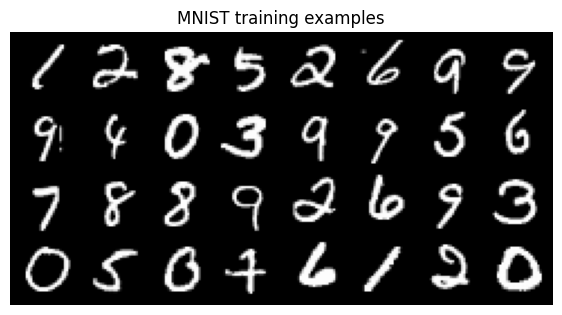

In [6]:
def show_tensor_images(x, title=None, nrow=8, figsize=(7, 7)):
    x = x.detach().cpu()
    x = (x.clamp(-1, 1) + 1) / 2
    grid = make_grid(x, nrow=nrow, padding=2)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


show_tensor_images(images[:32], "MNIST training examples")

## 3. DDPM Forward Diffusion

The forward process gradually corrupts a clean image $\mathbf{x}_0 \sim q(\mathbf{x})$ with a fixed Markov chain:

$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) =
\mathcal{N}\left(\mathbf{x}_t; \sqrt{1 - \beta_t}\,\mathbf{x}_{t-1}, \beta_t \mathbf{I}\right),
\qquad
q(\mathbf{x}_{1:T} \mid \mathbf{x}_0) = \prod_{t=1}^{T} q(\mathbf{x}_t \mid \mathbf{x}_{t-1}).
$$

Define

$$
\alpha_t = 1 - \beta_t, \qquad \bar{\alpha}_t = \prod_{i=1}^{t} \alpha_i.
$$

Because the transition is Gaussian, repeated substitution gives a closed-form marginal at any timestep:

$$
q(\mathbf{x}_t \mid \mathbf{x}_0) =
\mathcal{N}\left(\mathbf{x}_t; \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0, (1 - \bar{\alpha}_t)\mathbf{I}\right).
$$

Equivalently, using the reparameterization trick with $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$,

$$
\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\,\boldsymbol{\epsilon}.
$$

This closed form is why training does not need to simulate all intermediate noising steps. For each image, we sample one timestep $t$, sample one Gaussian noise tensor $\boldsymbol{\epsilon}$, construct $\mathbf{x}_t$ directly, and ask the network to predict that exact noise tensor from $(\mathbf{x}_t, t)$.

In [7]:
betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)


def extract(a, t, x_shape):
    """Extract values from a 1-D schedule tensor for a batch of timesteps."""
    batch_size = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)
    return (
        extract(sqrt_alphas_cumprod, t, x_start.shape) * x_start
        + extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape) * noise
    )

The tensors above mirror the mathematical schedule:

- `betas` stores $\beta_t$.
- `alphas` stores $\alpha_t = 1 - \beta_t$.
- `alphas_cumprod` stores $\bar{\alpha}_t$.
- `posterior_variance` stores $\tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t}\beta_t$, the variance of the tractable posterior $q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0)$.

The first posterior variance is zero because there is no stochastic step after reaching $\mathbf{x}_0$ during sampling.

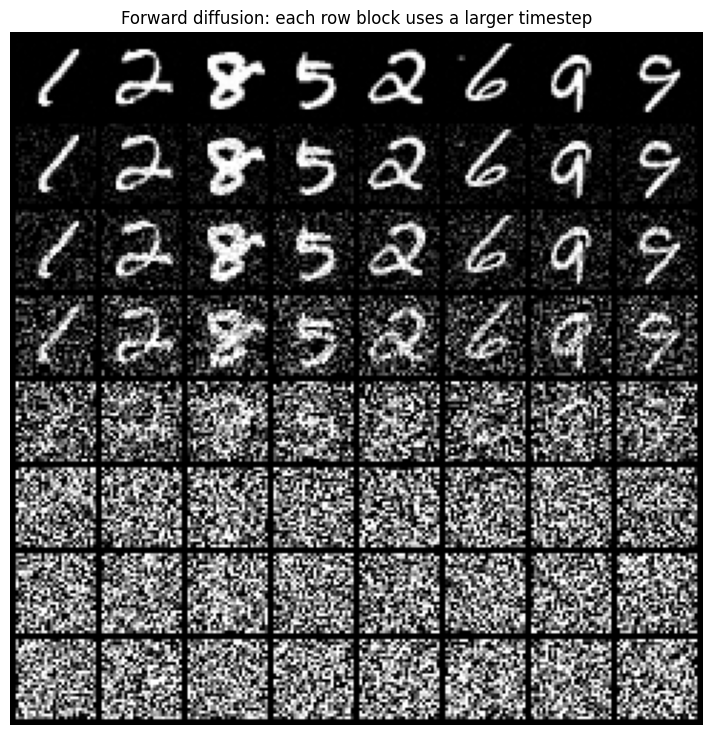

In [8]:
x0 = images[:8].to(device)
demo_steps = torch.tensor([0, 50, 100, 200, 400, 600, 800, 999], device=device)
demo = []
for t_scalar in demo_steps:
    t = torch.full((x0.size(0),), int(t_scalar.item()), device=device, dtype=torch.long)
    demo.append(q_sample(x0, t))

demo_grid = torch.cat(demo, dim=0)
show_tensor_images(demo_grid, "Forward diffusion: each row block uses a larger timestep", nrow=8, figsize=(9, 9))

## 4. U-Net with Time Embedding

The network predicts $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$, not a clean image directly. It is a small U-Net: downsample the image, process features at low resolution, then upsample while combining skip connections. Timestep information is injected into each residual block using sinusoidal embeddings followed by an MLP.

The sinusoidal embedding lets one shared network represent behavior across all noise levels. Early timesteps require small denoising corrections; late timesteps receive inputs that are close to isotropic Gaussian noise.

This model has roughly 2-3 million parameters, enough for MNIST without making the notebook too heavy.

In [9]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None].float() * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_channels))
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
        )
        self.residual = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t):
        h = self.block1(x)
        h = h + self.time_mlp(t)[:, :, None, None]
        h = self.block2(h)
        return h + self.residual(x)


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class SimpleUNet(nn.Module):
    def __init__(self, image_channels=1, base_channels=40, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.init_conv = nn.Conv2d(image_channels, base_channels, 3, padding=1)

        self.down1 = ResidualBlock(base_channels, base_channels, time_emb_dim)
        self.downsample1 = Downsample(base_channels)      # 28 -> 14
        self.down2 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim)
        self.downsample2 = Downsample(base_channels * 2)  # 14 -> 7
        self.down3 = ResidualBlock(base_channels * 2, base_channels * 4, time_emb_dim)

        self.mid1 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim)
        self.mid2 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        self.up3 = ResidualBlock(base_channels * 8, base_channels * 2, time_emb_dim)
        self.upsample2 = Upsample(base_channels * 2)      # 7 -> 14
        self.up2 = ResidualBlock(base_channels * 4, base_channels, time_emb_dim)
        self.upsample1 = Upsample(base_channels)          # 14 -> 28
        self.up1 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim)

        self.out = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, image_channels, 1),
        )

    def forward(self, x, time):
        t = self.time_mlp(time)

        x = self.init_conv(x)
        s1 = self.down1(x, t)
        x = self.downsample1(s1)
        s2 = self.down2(x, t)
        x = self.downsample2(s2)
        s3 = self.down3(x, t)

        x = self.mid1(s3, t)
        x = self.mid2(x, t)

        x = self.up3(torch.cat([x, s3], dim=1), t)
        x = self.upsample2(x)
        x = self.up2(torch.cat([x, s2], dim=1), t)
        x = self.upsample1(x)
        x = self.up1(torch.cat([x, s1], dim=1), t)
        return self.out(x)


model = SimpleUNet(image_channels=cfg.channels).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params / 1e6:.2f}M")

Model parameters: 2.43M


## 5. Training Objective

The reverse model is

$$
p_\theta(\mathbf{x}_{0:T}) = p(\mathbf{x}_T) \prod_{t=1}^{T} p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t),
\qquad
p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t) =
\mathcal{N}\left(\mathbf{x}_{t-1}; \boldsymbol{\mu}_\theta(\mathbf{x}_t, t), \boldsymbol{\Sigma}_\theta(\mathbf{x}_t, t)\right).
$$

The true reverse conditional $q(\mathbf{x}_{t-1} \mid \mathbf{x}_t)$ is not directly available, because it depends on the unknown data distribution. The posterior conditioned on $\mathbf{x}_0$ is tractable. By Bayes' rule,

$$
q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0) =
q(\mathbf{x}_t \mid \mathbf{x}_{t-1}, \mathbf{x}_0)\frac{q(\mathbf{x}_{t-1} \mid \mathbf{x}_0)}{q(\mathbf{x}_t \mid \mathbf{x}_0)},
$$

and substituting the Gaussian forward marginals gives

$$
q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0) =
\mathcal{N}\left(\mathbf{x}_{t-1}; \tilde{\boldsymbol{\mu}}_t(\mathbf{x}_t, \mathbf{x}_0), \tilde{\beta}_t\mathbf{I}\right),
$$

where

$$
\tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t}\beta_t,
$$

and

$$
\tilde{\boldsymbol{\mu}}_t(\mathbf{x}_t, \mathbf{x}_0) =
\frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t}\mathbf{x}_t
+ \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1 - \bar{\alpha}_t}\mathbf{x}_0.
$$

Using the forward-process reparameterization,

$$
\mathbf{x}_0 = \frac{1}{\sqrt{\bar{\alpha}_t}}\left(\mathbf{x}_t - \sqrt{1 - \bar{\alpha}_t}\,\boldsymbol{\epsilon}\right),
$$

this posterior mean can be written as

$$
\tilde{\boldsymbol{\mu}}_t(\mathbf{x}_t, \boldsymbol{\epsilon}) =
\frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\boldsymbol{\epsilon}\right).
$$

DDPM trains by minimizing a variational upper bound on $-\log p_\theta(\mathbf{x}_0)$:

$$
L_{\mathrm{VLB}} =
\mathbb{E}_q\left[
D_{\mathrm{KL}}(q(\mathbf{x}_T \mid \mathbf{x}_0) \parallel p(\mathbf{x}_T))
+ \sum_{t=2}^{T} D_{\mathrm{KL}}(q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0) \parallel p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t))
- \log p_\theta(\mathbf{x}_0 \mid \mathbf{x}_1)
\right].
$$

For fixed reverse variance, each intermediate KL is a Gaussian-to-Gaussian comparison. Therefore fitting $\boldsymbol{\mu}_\theta$ is equivalent to fitting the posterior mean. Rather than predicting the mean directly, DDPM parameterizes it through a predicted noise tensor:

$$
\boldsymbol{\mu}_\theta(\mathbf{x}_t, t) =
\frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right).
$$

Substituting this into the KL yields a weighted noise-prediction loss,

$$
L_t \propto
\mathbb{E}_{\mathbf{x}_0,\boldsymbol{\epsilon}}\left[
\frac{\beta_t^2}{2\alpha_t(1 - \bar{\alpha}_t)\sigma_t^2}
\left\lVert \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}, t) \right\rVert^2
\right].
$$

Ho et al. found that the simplified unweighted objective works well in practice:

$$
L_{\mathrm{simple}} =
\mathbb{E}_{t,\mathbf{x}_0,\boldsymbol{\epsilon}}\left[
\left\lVert \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \right\rVert^2
\right].
$$

That is what `p_losses` implements.

For each image in a batch:

1. Sample a random timestep `t`.
2. Sample Gaussian noise $\boldsymbol{\epsilon}$.
3. Create $\mathbf{x}_t$ using the closed-form forward process.
4. Ask the U-Net to predict $\boldsymbol{\epsilon}$.
5. Minimize MSE between predicted noise and true noise.

The score-model view is consistent with this parameterization: for the Gaussian corruption distribution,

$$
\nabla_{\mathbf{x}_t}\log q(\mathbf{x}_t \mid \mathbf{x}_0)
= -\frac{\boldsymbol{\epsilon}}{\sqrt{1 - \bar{\alpha}_t}},
$$

so predicting noise also estimates the score up to the known scale factor $-1/\sqrt{1 - \bar{\alpha}_t}$.

In [10]:
def p_losses(denoise_model, x_start, t):
    noise = torch.randn_like(x_start)
    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = denoise_model(x_noisy, t)
    return F.mse_loss(predicted_noise, noise)


optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
loss_history = []

## 6. Train

The default is 20 epochs. For a quick smoke test, temporarily lower `cfg.epochs` in the configuration cell. Better samples usually appear after several epochs on GPU.

In [11]:
model.train()

for epoch in range(1, cfg.epochs + 1):
    running_loss = 0.0
    for step, (batch, _) in enumerate(train_loader, start=1):
        batch = batch.to(device)
        t = torch.randint(0, cfg.timesteps, (batch.size(0),), device=device).long()

        loss = p_losses(model, batch, t)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch:02d}/{cfg.epochs} | loss: {epoch_loss:.4f}")

Epoch 01/20 | loss: 0.0625
Epoch 02/20 | loss: 0.0325
Epoch 03/20 | loss: 0.0286
Epoch 04/20 | loss: 0.0273
Epoch 05/20 | loss: 0.0262
Epoch 06/20 | loss: 0.0257
Epoch 07/20 | loss: 0.0251
Epoch 08/20 | loss: 0.0247
Epoch 09/20 | loss: 0.0243
Epoch 10/20 | loss: 0.0243
Epoch 11/20 | loss: 0.0237
Epoch 12/20 | loss: 0.0237
Epoch 13/20 | loss: 0.0237
Epoch 14/20 | loss: 0.0232
Epoch 15/20 | loss: 0.0229
Epoch 16/20 | loss: 0.0232
Epoch 17/20 | loss: 0.0231
Epoch 18/20 | loss: 0.0229
Epoch 19/20 | loss: 0.0227
Epoch 20/20 | loss: 0.0229


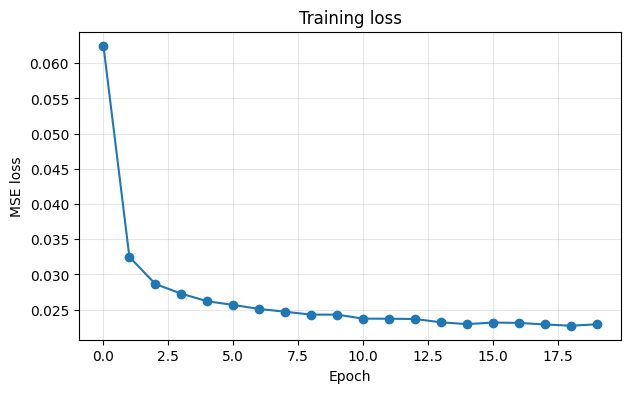

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.show()

## 7. Reverse Diffusion Sampling

Sampling starts from pure Gaussian noise

$$
\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I}).
$$

At each timestep, the model predicts $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ and plugs it into the DDPM reverse mean:

$$
\boldsymbol{\mu}_\theta(\mathbf{x}_t, t) =
\frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right).
$$

The sampler then draws

$$
\mathbf{x}_{t-1} = \boldsymbol{\mu}_\theta(\mathbf{x}_t, t) + \sigma_t \mathbf{z},
\qquad
\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}),
$$

with $\sigma_t^2 = \tilde{\beta}_t$ in this notebook. No extra noise is added on the final step, so the last update returns the mean directly. This matches the standard DDPM sampling algorithm for a fixed variance schedule.

In [13]:
@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    model_mean = sqrt_recip_alphas_t * (x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t)

    if t_index == 0:
        return model_mean
    posterior_variance_t = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x)
    return model_mean + torch.sqrt(posterior_variance_t) * noise


@torch.no_grad()
def sample(model, image_size=28, batch_size=16, channels=1, save_steps=None):
    model.eval()
    shape = (batch_size, channels, image_size, image_size)
    img = torch.randn(shape, device=device)
    imgs = []
    save_steps = set(save_steps or [])

    for i in reversed(range(cfg.timesteps)):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)
        img = p_sample(model, img, t, i)
        if i in save_steps:
            imgs.append((i, img.detach().cpu()))
    model.train()
    return img.detach().cpu(), imgs

## 8. Generate Digits

The generated images below are sampled from random noise. If the model is undertrained, the output may look fuzzy; more training improves the distribution.

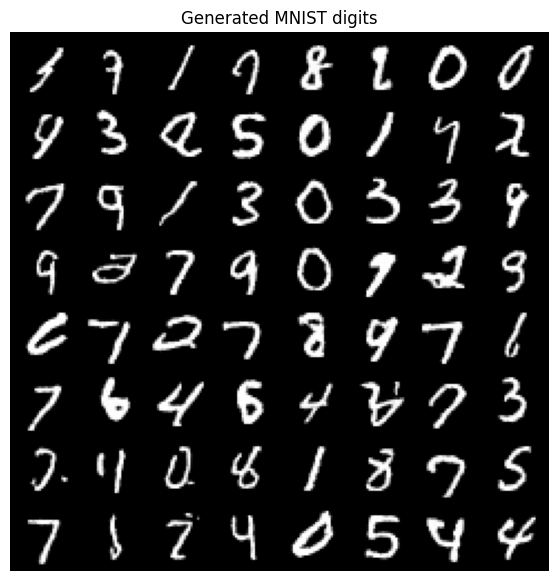

In [14]:
generated, _ = sample(model, image_size=cfg.image_size, batch_size=64, channels=cfg.channels)
show_tensor_images(generated, "Generated MNIST digits", nrow=8, figsize=(7, 7))

## 9. Visualize the Denoising Process

This cell stores a few reverse-process snapshots for the same samples, showing the path from noise to image.

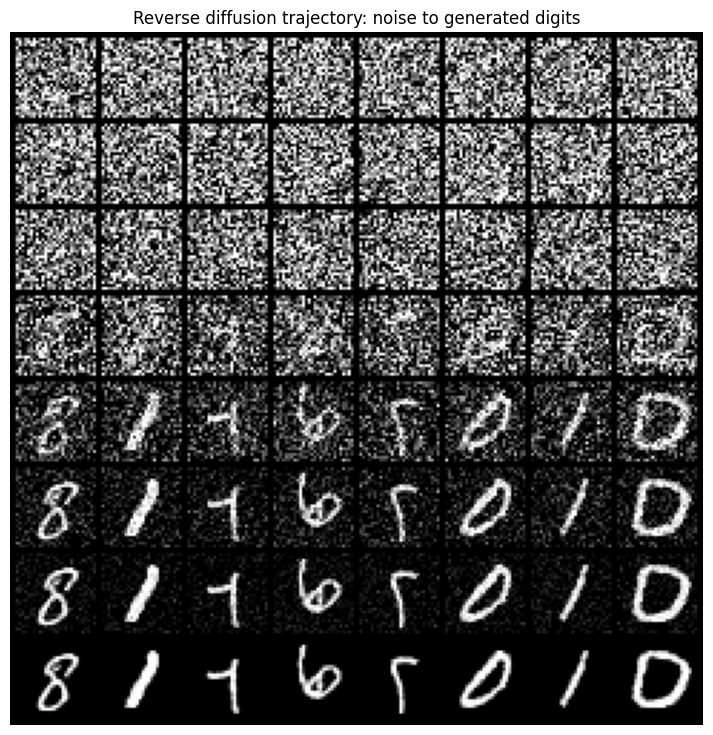

Saved timesteps: [999, 800, 600, 400, 200, 100, 50, 0]


In [15]:
trajectory_steps = [999, 800, 600, 400, 200, 100, 50, 0]
final_samples, trajectory = sample(
    model,
    image_size=cfg.image_size,
    batch_size=8,
    channels=cfg.channels,
    save_steps=trajectory_steps,
)

trajectory = sorted(trajectory, key=lambda item: item[0], reverse=True)
trajectory_images = torch.cat([imgs[:8] for _, imgs in trajectory], dim=0)
show_tensor_images(trajectory_images, "Reverse diffusion trajectory: noise to generated digits", nrow=8, figsize=(9, 9))
print("Saved timesteps:", [t for t, _ in trajectory])

## 10. Optional: Save and Reload Weights

Uncomment these lines if you want to keep the trained model for later sampling.

In [16]:
torch.save(model.state_dict(), "ddpm_mnist_unet.pt")
model.load_state_dict(torch.load("ddpm_mnist_unet.pt", map_location=device))

<All keys matched successfully>